# Patch-Resolved Radiator Earth View Factor

This notebook uses one working model only:

- a rectangular radiator panel, `20 x 30 mm`
- sampled on a patch grid
- mounted on the `+Y` or `-Y` body face
- with a simple recessed sidewall geometry to create real panel spread
- Earth resolved as a visible disk and integrated directly in solid angle

The result is a panel-resolved Earth view factor map and a panel-averaged `±Y` curve over the orbit.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

from geometry import (
    Orbit,
    TargetTracking,
    SunTracking,
    SlewModeSwitch,
    RectangularPanel,
    panel_loading_propagate,
)

SGR_A = (math.radians(266.4168), math.radians(-29.0078))

orbit = Orbit.from_epoch(
    a=6771e3,
    i=math.radians(51.6),
    omega=math.radians(30.0),
    epoch=datetime(2025, 7, 21, 12, 0, 0),
)

slew_rate_deg_s = 1

dual_law = SlewModeSwitch(
    eclipse_law=TargetTracking(*SGR_A),
    sunlit_law=SunTracking(),
    slew_rate_deg_s=slew_rate_deg_s,
)

# 20 x 30 mm radiator, sampled at 1 mm pitch, recessed in a 5 mm cavity.
panel = RectangularPanel(
    width=20e-3,
    height=30e-3,
    nx=20,
    ny=30,
    wall_height=5e-3,
)

prof_py = panel_loading_propagate(
    orbit,
    dual_law,
    panel,
    face='+Y',
    n=180,
    n_mu=18,
    n_az=72,
)
prof_ny = panel_loading_propagate(
    orbit,
    dual_law,
    panel,
    face='-Y',
    n=180,
    n_mu=18,
    n_az=72,
)

avg_both = 0.5 * (prof_py.average_view() + prof_ny.average_view())
peak_idx = int(avg_both.argmax())
peak_u_deg = float(np.degrees(prof_py.u[peak_idx]))

print(f"Panel        : {panel.width * 1e3:.0f} x {panel.height * 1e3:.0f} mm")
print(f"Patch grid   : {panel.nx} x {panel.ny}")
print(f"Wall height  : {panel.wall_height * 1e3:.1f} mm")
print(f"Slew rate    : {slew_rate_deg_s:.2f} deg/s")
print(f"Orbit samples: {len(prof_py.u)}")
print(f"+Y avg range : {prof_py.average_view().min():.3f} .. {prof_py.average_view().max():.3f}")
print(f"-Y avg range : {prof_ny.average_view().min():.3f} .. {prof_ny.average_view().max():.3f}")
print(f"Peak snapshot: u = {peak_u_deg:.1f} deg")


Panel        : 20 x 30 mm
Patch grid   : 20 x 30
Wall height  : 5.0 mm
Slew rate    : 1.00 deg/s
Orbit samples: 230
+Y avg range : 0.171 .. 0.435
-Y avg range : 0.021 .. 0.183
Peak snapshot: u = 343.4 deg


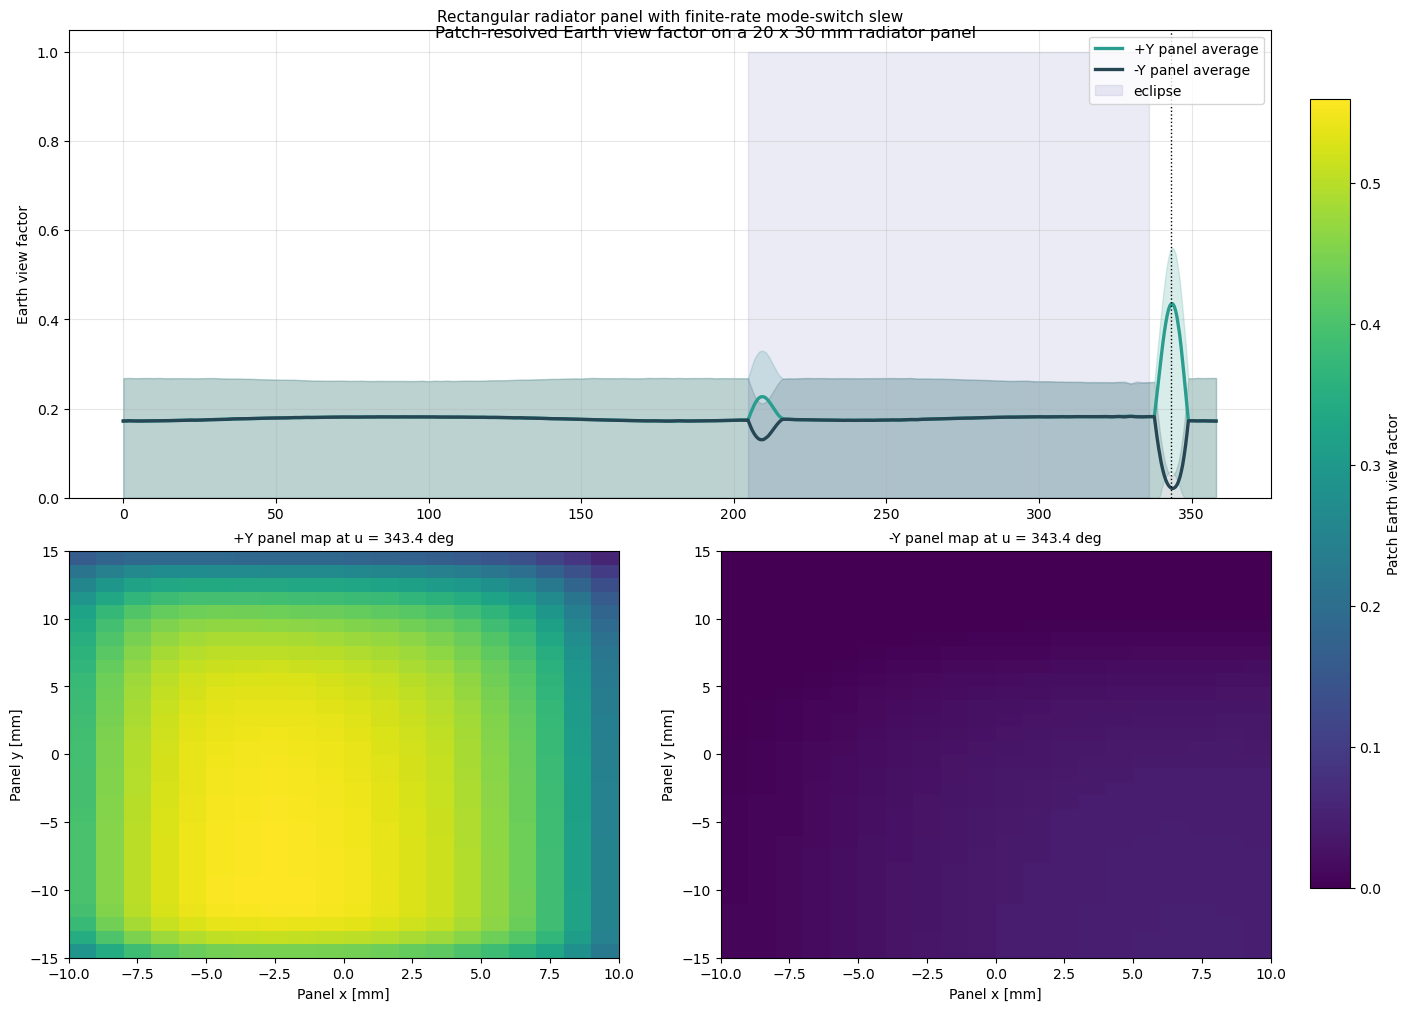

In [2]:
u_deg = np.degrees(prof_py.u)
x_mm = np.linspace(-0.5 * panel.width * 1e3, 0.5 * panel.width * 1e3, panel.nx)
y_mm = np.linspace(-0.5 * panel.height * 1e3, 0.5 * panel.height * 1e3, panel.ny)
extent = [x_mm.min(), x_mm.max(), y_mm.min(), y_mm.max()]

py_map = prof_py.view[peak_idx]
ny_map = prof_ny.view[peak_idx]
vmax = max(float(py_map.max()), float(ny_map.max()))

fig = plt.figure(figsize=(14, 10), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.15, 1.0])

ax = fig.add_subplot(gs[0, :])
ax.plot(u_deg, prof_py.average_view(), color='#2a9d8f', lw=2.4, label='+Y panel average')
ax.fill_between(u_deg, prof_py.min_view(), prof_py.max_view(), color='#2a9d8f', alpha=0.18)
ax.plot(u_deg, prof_ny.average_view(), color='#264653', lw=2.4, label='-Y panel average')
ax.fill_between(u_deg, prof_ny.min_view(), prof_ny.max_view(), color='#264653', alpha=0.16)
ax.axvline(peak_u_deg, color='black', ls=':', lw=1.0)
ax.fill_between(u_deg, 0, 1, where=prof_py.eclipse, alpha=0.08, color='navy', label='eclipse')
ax.set_ylabel('Earth view factor')
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.set_title('Rectangular radiator panel with finite-rate mode-switch slew', fontsize=11)

ax = fig.add_subplot(gs[1, 0])
im = ax.imshow(py_map, origin='lower', extent=extent, aspect='auto', vmin=0.0, vmax=vmax, cmap='viridis')
ax.set_xlabel('Panel x [mm]')
ax.set_ylabel('Panel y [mm]')
ax.set_title(f'+Y panel map at u = {peak_u_deg:.1f} deg', fontsize=10)

ax = fig.add_subplot(gs[1, 1])
ax.imshow(ny_map, origin='lower', extent=extent, aspect='auto', vmin=0.0, vmax=vmax, cmap='viridis')
ax.set_xlabel('Panel x [mm]')
ax.set_ylabel('Panel y [mm]')
ax.set_title(f'-Y panel map at u = {peak_u_deg:.1f} deg', fontsize=10)

cbar = fig.colorbar(im, ax=fig.axes, shrink=0.85, pad=0.02)
cbar.set_label('Patch Earth view factor')

fig.suptitle(
    'Patch-resolved Earth view factor on a 20 x 30 mm radiator panel',
    fontsize=12,
    y=0.98,
)
plt.show()


The spread here comes from the recessed-wall geometry. If `wall_height = 0`, the panel becomes fully open and the patch map collapses toward a uniform flat-face result.